In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/netflix_titles (1).csv')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.shape

(8807, 12)

In [ ]:
# Check null values column-wise
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.isnull().sum().sum()

np.int64(4307)

In [ ]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


Check for Inconsistent Categories

Check unique values

In [ ]:
df['country'].unique()
df['rating'].unique()
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

 Check value counts

In [ ]:
df['country'].value_counts().head(10)
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


Handle Nulls, Duplicates & Inconsistent Categories


 Remove Duplicates

In [ ]:
df.drop_duplicates(inplace=True)

Handle Null Values

In [ ]:
df.fillna({
    'director': 'Unknown',
    'cast': 'Not Available',
    'country': 'Unknown',
    'rating': 'Not Rated'
}, inplace=True)

task 24 feb

Fix Inconsistent Categories
Remove extra spaces

In [ ]:
df['country'] = df['country'].str.strip()
df['rating'] = df['rating'].str.strip()
df['type'] = df['type'].str.strip()

Make categories consistent (lowercase example)

In [ ]:
df['country'] = df['country'].str.title()
df['rating'] = df['rating'].str.upper()

Check

In [ ]:
df.isnull().sum()
df.duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Normalize Country Column**

In [ ]:
df['country'] = df['country'].str.strip()
df['country'] = df['country'].str.title()

Normalize Rating Column

In [ ]:
df['rating'] = df['rating'].str.strip()
df['rating'] = df['rating'].str.upper()

Normalize Type Column


In [ ]:
df['type'] = df['type'].str.strip()
df['type'] = df['type'].str.title()

Normalize Genre (listed_in Column)

In [ ]:
df['listed_in'] = df['listed_in'].str.strip()
df['listed_in'] = df['listed_in'].str.title()

Split Multiple Countries

In [ ]:
df['country'] = df['country'].apply(
    lambda x: ', '.join([c.strip().title() for c in str(x).split(',')])
)


Check

In [ ]:
df['country'].unique()
df['rating'].unique()
df['listed_in'].head()

,listed_in
0,Documentaries
1,"International Tv Shows, Tv Dramas, Tv Mysteries"
2,"Crime Tv Shows, International Tv Shows, Tv Act..."
3,"Docuseries, Reality Tv"
4,"International Tv Shows, Romantic Tv Shows, Tv ..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


date
Remove Extra Spaces

In [ ]:
df['date_added'] = df['date_added'].str.strip()

Convert to Datetime

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

check

In [ ]:
df['date_added'].dtype

dtype('<M8[ns]')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality Tv","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In a city of coaching centers known to train I...


In [ ]:
df['date_added'] = df['date_added'].fillna(
    pd.to_datetime(df['release_year'], format='%Y')
)

Missing Dates

10 rows have NaT (missing)

In [ ]:
df[df['date_added'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [ ]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nRelease Year Range:", df['release_year'].min(), "-", df['release_year'].max())
print("\nUnique Content Types:", df['type'].unique())
print("\nUnique Ratings:", df['rating'].unique())

Missing Values:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

Duplicate Rows: 0

Release Year Range: 1925 - 2021

Unique Content Types: ['Movie' 'Tv Show']

Unique Ratings: ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 MIN' '84 MIN' '66 MIN' 'NR' 'NOT RATED' 'TV-Y7-FV' 'UR']


**Task**  3 march

Convert to lowercase
columns country, rating, listed in

In [ ]:
df['country'] = df['country'].str.lower()
df['rating'] = df['rating'].str.lower()
df['listed_in'] = df['listed_in'].str.lower()

Remove Unwanted Spaces

In [ ]:
df['country'] = df['country'].str.strip()
df['rating'] = df['rating'].str.strip()
df['listed_in'] = df['listed_in'].str.strip()

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...


*5* march task

Analyze Netflix Content Growth Over Time

In [ ]:
df['year_added'] = df['date_added'].dt.year

growth over time

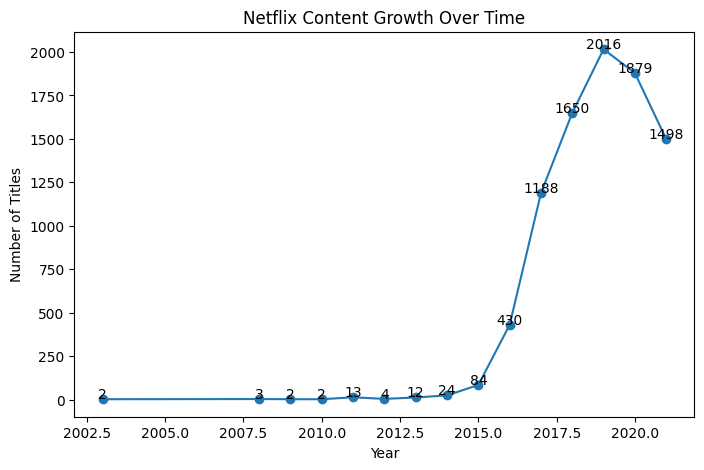

In [ ]:
counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(counts.index, counts.values, marker='o')

for x, y in zip(counts.index, counts.values):
    plt.text(x, y+5, str(y), ha='center')

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

Distribution of Content Type Movie vs TV Show

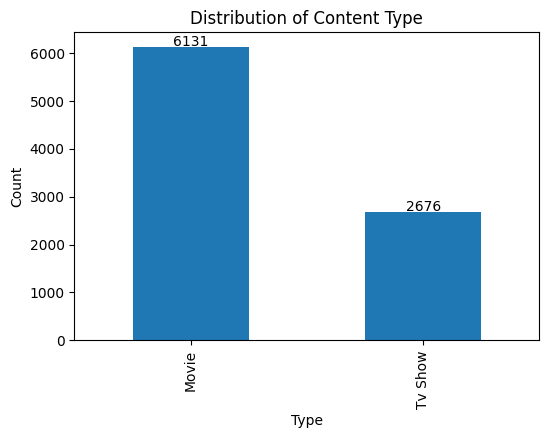

In [ ]:
import matplotlib.pyplot as plt

counts = df['type'].value_counts()

ax = counts.plot(kind='bar', figsize=(6,4))

plt.title("Distribution of Content Type")
plt.xlabel("Type")
plt.ylabel("Count")

# Add numbers on bars
for i, v in enumerate(counts):
    ax.text(i, v + 20, str(v), ha='center')

plt.show()

Distribution of Ratings

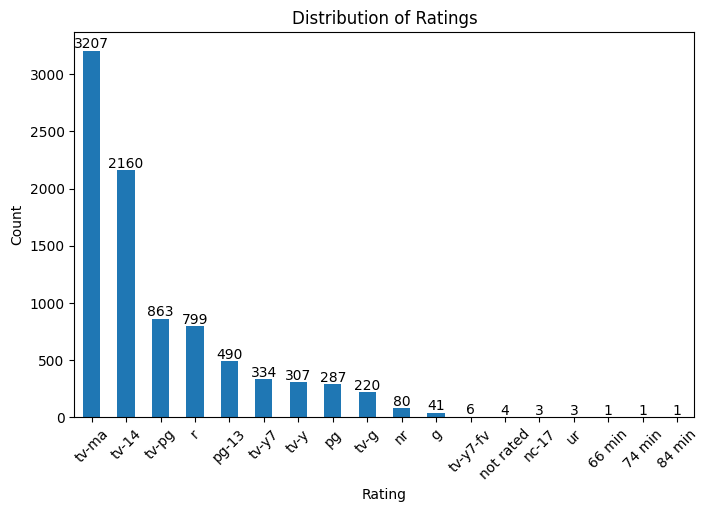

In [ ]:
counts = df['rating'].value_counts()

ax = counts.plot(kind='bar', figsize=(8,5))

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)

for i, v in enumerate(counts):
    ax.text(i, v + 20, str(v), ha='center')

plt.show()

Distribution of Genres

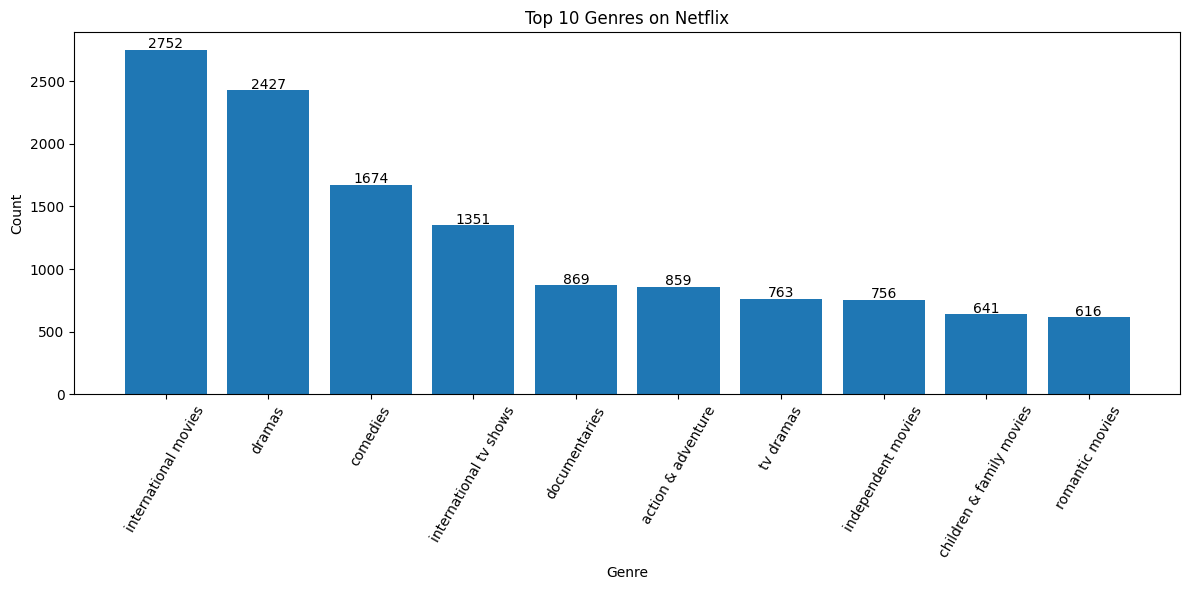

In [ ]:
from collections import Counter

genre_count = Counter()

for genres in df['listed_in']:
    for g in genres.split(','):
        genre_count[g.strip()] += 1

top_genres = dict(genre_count.most_common(10))

plt.figure(figsize=(12,6))
bars = plt.bar(top_genres.keys(), top_genres.values())

plt.xticks(rotation=60)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")

# Add numbers on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center')

plt.tight_layout()
plt.show()

Task 6 **march**

Country-Level Content Contributions

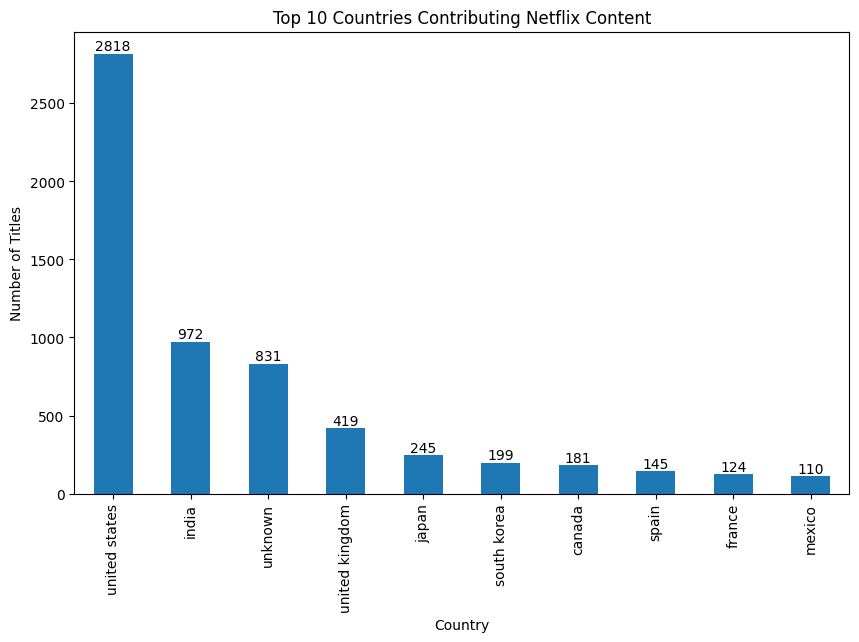

In [ ]:
import matplotlib.pyplot as plt

top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
ax = top_countries.plot(kind='bar')

plt.title("Top 10 Countries Contributing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

# Add numbers on bars
for i, v in enumerate(top_countries):
    ax.text(i, v + 20, str(v), ha='center')

plt.show()


Create Derived Feature: Content Length Category

In [ ]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_218/710516317.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


In [ ]:
def length_category(x):
    if x < 60:
        return "Short"
    elif x < 120:
        return "Medium"
    else:
        return "Long"

df['content_length_category'] = df['duration_num'].apply(length_category)

In [ ]:
df[['duration','duration_num','content_length_category']].head()

,duration,duration_num,content_length_category
0,90 min,90.0,Medium
1,2 Seasons,2.0,Short
2,1 Season,1.0,Short
3,1 Season,1.0,Short
4,2 Seasons,2.0,Short


Derived Feature: Original vs Licensed

In [ ]:
df['content_origin'] = df['country'].apply(
    lambda x: "Original" if "United States" in str(x) else "Licensed"
)

In [ ]:
df[['country','content_origin']].head()

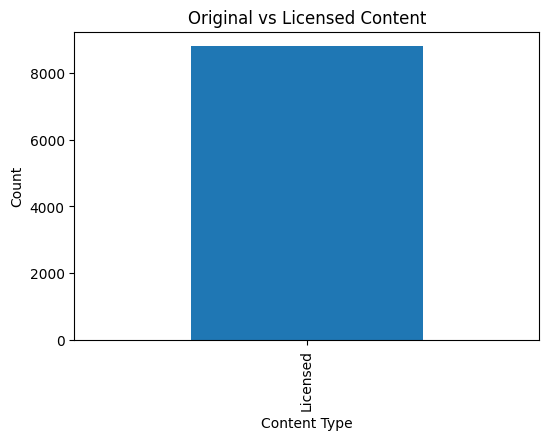

In [ ]:
import matplotlib.pyplot as plt

origin_counts = df['content_origin'].value_counts()

plt.figure(figsize=(6,4))
origin_counts.plot(kind='bar')

plt.title("Original vs Licensed Content")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()